# 02: IAM Handwriting Word Recognition (CRNN + CTC)

This notebook implements a Convolutional Recurrent Neural Network (CRNN) with Connectionist Temporal Classification (CTC) for end-to-end handwriting recognition on the IAM Word Database.

In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from collections import Counter
import random
import editdistance

## 1. Configuration

In [2]:
IMAGE_WIDTH = 128
IMAGE_HEIGHT = 32
MAX_SEQ_LENGTH = 32
USE_ONLY_OK = True
BATCH_SIZE = 64
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## 2. Dataset Loading & Vocabulary Definition

Load `words.txt` and `form.txt`, join them, and build the full vocabulary BEFORE filtering.

In [3]:
words_path = "../data/IAM/words.txt"
form_path = "../data/IAM/form.txt"

parsed_words = []
with open(words_path, "r") as f:
    for line in f:
        if line.startswith("#") or not line.strip(): continue
        parts = line.strip().split(" ", 8)
        if len(parts) < 9: continue
        word_id = parts[0]
        seg_res = parts[1]
        transcription = parts[8]
        form_id = "-".join(word_id.split("-")[:2])
        parsed_words.append({
            "word_id": word_id,
            "form_id": form_id,
            "seg_res": seg_res,
            "transcription": transcription
        })
df_words = pd.DataFrame(parsed_words)

parsed_forms = []
with open(form_path, "r") as f:
    for line in f:
        if line.startswith("#") or not line.strip(): continue
        parts = line.strip().split(" ")
        parsed_forms.append({"form_id": parts[0], "writer_id": parts[1]})
df_forms = pd.DataFrame(parsed_forms)

df = pd.merge(df_words, df_forms, on="form_id", how="inner")

print(f"Total initial records: {len(df)}")

# Build fixed 79-character vocabulary BEFORE any filtering
vocab = set()
for t in df["transcription"]:
    vocab.update(list(t))
vocab = sorted(list(vocab))
print(f"Vocabulary size (excluding blank): {len(vocab)}")

char_to_num = {c: i + 1 for i, c in enumerate(vocab)} # Index 1 to 79
num_to_char = {i: c for c, i in char_to_num.items()}

NUM_CLASSES = len(vocab) + 1 # +1 for CTC blank
BLANK_INDEX = 0
print(f"Total output classes (including blank at index {BLANK_INDEX}): {NUM_CLASSES}")

# Explicit Assertions
assert len(vocab) == 79, f"Expected 79 characters, got {len(vocab)}"
assert set(char_to_num.values()) == set(range(1, 80)), "Character indices must be 1..79"
assert BLANK_INDEX == 0, "CTC Blank index must be 0"
assert NUM_CLASSES == 80, "Total classes must be exactly 80"
assert 0 not in char_to_num.values(), "No real character should use index 0"
print("CTC consistency checks passed.")


Total initial records: 115320
Vocabulary size (excluding blank): 79
Total output classes (including blank at index 0): 80
CTC consistency checks passed.


## 3. Filtering & CTC Feasibility Check

Filter out segmentations, verify sequence lengths, and enforce CTC feasibility.

In [4]:
if USE_ONLY_OK:
    df = df[df["seg_res"] == "ok"].copy()
    
# Remove transcription outliers (e.g., malformed lines)
df = df[~df["transcription"].str.contains(r'[-]{4,}')] # Remove consecutive hyphens 4+

# CTC Feasibility Check
def get_ctc_required_length(text):
    if len(text) == 0: return 0
    req_len = 1
    for i in range(1, len(text)):
        req_len += 1
        if text[i] == text[i-1]:
            req_len += 1
    return req_len

df['ctc_required_length'] = df['transcription'].apply(get_ctc_required_length)
model_time_steps = IMAGE_WIDTH // 4 # 32

infeasible = df[df['ctc_required_length'] > model_time_steps]
df = df[df['ctc_required_length'] <= model_time_steps]
df = df[df['transcription'].str.len() > 0] # Remove empty transcripts

print(f"Model time steps: {model_time_steps}")
print(f"Maximum label length: {df['transcription'].str.len().max()}")
print(f"Maximum CTC-required length: {df['ctc_required_length'].max()}")
print(f"Samples removed due to CTC-infeasible length: {len(infeasible)}")
print(f"Records after feasibility filtering: {len(df)}")


Model time steps: 32
Maximum label length: 21
Maximum CTC-required length: 22
Samples removed due to CTC-infeasible length: 0
Records after feasibility filtering: 96456


## 3.5 Image Validation Preflight

Verify that all filtered images physically exist, are non-empty, and can be read by OpenCV.

In [5]:
invalid_samples = []
valid_indices = []

for i, row in df.iterrows():
    word_id = row['word_id']
    parts = word_id.split("-")
    img_path = f"../data/IAM/words/{parts[0]}/{parts[0]}-{parts[1]}/{word_id}.png"
    
    if not os.path.exists(img_path):
        invalid_samples.append({"word_id": word_id, "image_path": img_path, "reason": "File does not exist"})
        continue
        
    if os.path.getsize(img_path) == 0:
        invalid_samples.append({"word_id": word_id, "image_path": img_path, "reason": "File size is 0 bytes"})
        continue
        
    try:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            invalid_samples.append({"word_id": word_id, "image_path": img_path, "reason": "cv2 failed to decode image"})
            continue
            
        h, w = img.shape
        if h == 0 or w == 0:
            invalid_samples.append({"word_id": word_id, "image_path": img_path, "reason": "Image has 0 dimension"})
            continue
    except Exception as e:
        invalid_samples.append({"word_id": word_id, "image_path": img_path, "reason": f"Exception: {str(e)}"})
        continue
        
    valid_indices.append(i)

print(f"Number of raw samples before preflight: {len(df)}")
df = df.loc[valid_indices].copy()
print(f"Number of invalid samples removed: {len(invalid_samples)}")
print(f"Number of valid samples remaining: {len(df)}")

if invalid_samples:
    print("\nExcluded Samples Report:")
    for sample in invalid_samples:
        print(f"- {sample['word_id']} ({sample['reason']}): {sample['image_path']}")


Number of raw samples before preflight: 96456
Number of invalid samples removed: 2
Number of valid samples remaining: 96454

Excluded Samples Report:
- a01-117-05-02 (File size is 0 bytes): ../data/IAM/words/a01/a01-117/a01-117-05-02.png
- r06-022-03-05 (File size is 0 bytes): ../data/IAM/words/r06/r06-022/r06-022-03-05.png


## 4. EDA & Visualization

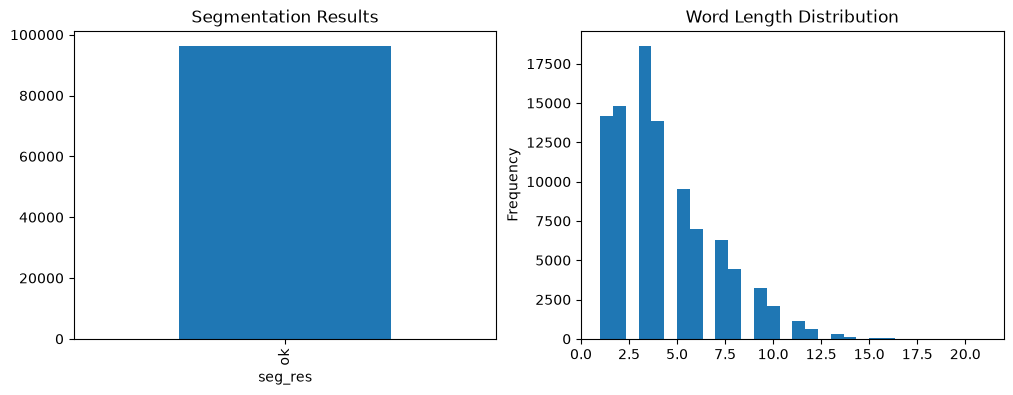

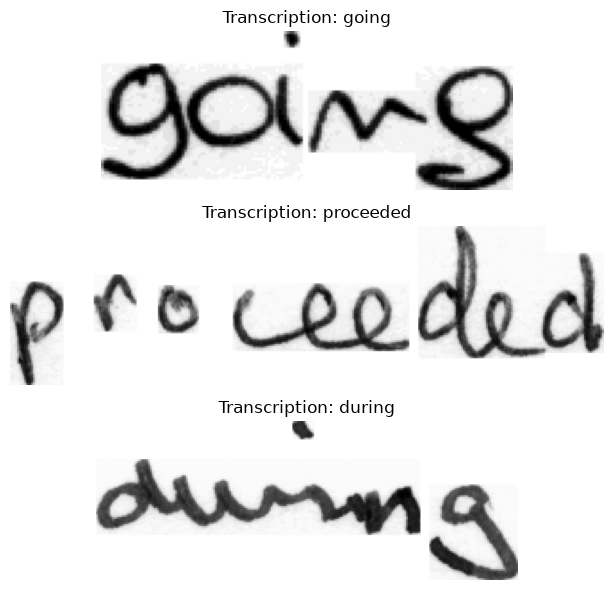

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['seg_res'].value_counts().plot(kind='bar', ax=axes[0], title='Segmentation Results')
df['transcription'].str.len().plot(kind='hist', bins=30, ax=axes[1], title='Word Length Distribution')
plt.show()

# Sample visualizations
fig, axes = plt.subplots(3, 1, figsize=(10, 6))
sample_df = df.sample(3, random_state=RANDOM_SEED)
for ax, (_, row) in zip(axes, sample_df.iterrows()):
    parts = row['word_id'].split("-")
    img_path = f"../data/IAM/words/{parts[0]}/{parts[0]}-{parts[1]}/{row['word_id']}.png"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Transcription: {row['transcription']}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## 5. Writer-Aware Splitting

Ensure no writer overlaps between splits.

In [7]:
writers = df["writer_id"].unique().tolist()
random.shuffle(writers)

n_writers = len(writers)
train_writers = set(writers[:int(0.8 * n_writers)])
val_writers = set(writers[int(0.8 * n_writers):int(0.9 * n_writers)])
test_writers = set(writers[int(0.9 * n_writers):])

# Overlap checks
assert len(train_writers.intersection(val_writers)) == 0, "Overlap train/val"
assert len(train_writers.intersection(test_writers)) == 0, "Overlap train/test"
assert len(val_writers.intersection(test_writers)) == 0, "Overlap val/test"
print("Zero writer overlap explicitly verified.")

train_df = df[df["writer_id"].isin(train_writers)].copy()
val_df = df[df["writer_id"].isin(val_writers)].copy()
test_df = df[df["writer_id"].isin(test_writers)].copy()

print(f"Train: {len(train_writers)} writers, {len(train_df['form_id'].unique())} forms, {len(train_df)} samples")
print(f"Val: {len(val_writers)} writers, {len(val_df['form_id'].unique())} forms, {len(val_df)} samples")
print(f"Test: {len(test_writers)} writers, {len(test_df['form_id'].unique())} forms, {len(test_df)} samples")


Zero writer overlap explicitly verified.
Train: 525 writers, 1283 forms, 81124 samples
Val: 66 writers, 139 forms, 8534 samples
Test: 66 writers, 117 forms, 6796 samples


## 6. TensorFlow Dataset Pipeline

Encode single sample, preserving actual label lengths.

In [8]:
def process_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize_with_pad(img, target_height=IMAGE_HEIGHT, target_width=IMAGE_WIDTH)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.transpose(img, perm=[1, 0, 2]) # [WIDTH, HEIGHT, CHANNELS] for CTC temporal dimension
    return img

def encode_single_sample(word_id, transcription):
    # Decode scalar tensors safely
    word_id_str = word_id.numpy().decode("utf-8")
    text = transcription.numpy().decode("utf-8")
    
    parts = word_id_str.split("-")
    image_path = f"../data/IAM/words/{parts[0]}/{parts[0]}-{parts[1]}/{word_id_str}.png"
    img = process_image(image_path)
    
    # Map chars to ints
    label = [char_to_num[c] for c in text]
    label_len = len(label)
    
    # Pad to MAX_SEQ_LENGTH. We pad with BLANK_INDEX (0). It will be ignored since we pass label_len.
    pad_len = MAX_SEQ_LENGTH - label_len
    padded_label = label + [BLANK_INDEX] * pad_len
    
    # Append the true length to the end of the tensor for the loss function: shape becomes [MAX_SEQ_LENGTH + 1]
    y_true_extended = padded_label + [label_len]
    return img, y_true_extended

def create_dataset(dataframe):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["word_id"].values,
        dataframe["transcription"].values
    ))
    dataset = dataset.map(
        lambda w, t: tf.py_function(encode_single_sample, [w, t], [tf.float32, tf.int32]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        lambda img, label_ext: (
            tf.ensure_shape(img, [IMAGE_WIDTH, IMAGE_HEIGHT, 1]),
            tf.ensure_shape(label_ext, [MAX_SEQ_LENGTH + 1])
        )
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)


## 7. Model Architecture

CNN extracts features, reshaping maps spatial to temporal (time = width), RNN models sequences.
The model must output raw logits because `tf.nn.ctc_loss` performs the softmax internally.

In [9]:
def build_model():
    input_img = layers.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 1), name="image")

    # CNN
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.MaxPooling2D((2, 2))(x) # Width -> 64, Height -> 16
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x) # Width -> 32, Height -> 8
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    
    # Reshape
    # Final image spatial dimensions: Width = 32, Height = 8, Channels = 128
    # We flatten the height into the channels for the temporal axis (Width)
    new_shape = (IMAGE_WIDTH // 4, (IMAGE_HEIGHT // 4) * 128) # (32, 1024)
    x = layers.Reshape(target_shape=new_shape)(x)
    x = layers.Dense(64, activation="relu")(x)

    # RNN
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # Output classes = 79 characters + 1 blank = 80
    # Explicitly using linear activation (raw logits) for tf.nn.ctc_loss
    output = layers.Dense(NUM_CLASSES, activation="linear", name="dense_output")(x)

    return models.Model(inputs=input_img, outputs=output, name="crnn_model")

model = build_model()
model.summary()


Model: "crnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 32, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 8, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32, 64)         │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 32, 80)         │        10,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,832 (2.02 MB)

 Trainable params: 530,704 (2.02 MB)

 Non-trainable params: 128 (512.00 B)

## 8. CTC Loss & Compilation

Extract the true label lengths stored in `y_true`.

In [10]:
def ctc_loss(y_true, y_pred):
    # Keras passes y_true as float32 during model.fit(), so we must cast it back to int32
    y_true = tf.cast(y_true, tf.int32)
    
    # y_true shape: [batch_size, MAX_SEQ_LENGTH + 1]
    # y_pred shape: [batch_size, time_steps, NUM_CLASSES] (RAW LOGITS)
    
    label_lengths = y_true[:, -1]
    y_true_actual = y_true[:, :-1]
    
    batch_len = tf.shape(y_true)[0]
    time_steps = tf.shape(y_pred)[1]
    
    input_lengths = tf.ones(shape=(batch_len,), dtype="int32") * tf.cast(time_steps, "int32")
    
    # Use tf.nn.ctc_loss directly to support blank_index=0
    # Inputs: labels, logits, label_length, logit_length, logits_time_major=False, blank_index=0
    loss = tf.nn.ctc_loss(
        labels=y_true_actual,
        logits=y_pred,
        label_length=label_lengths,
        logit_length=input_lengths,
        logits_time_major=False,
        blank_index=BLANK_INDEX
    )
    return tf.expand_dims(loss, 1)

model.compile(optimizer=tf.keras.optimizers.Adam(), loss=ctc_loss)


## 9. Pipeline Sanity Check

Validate shapes and CTC loss computation on a dummy batch.

In [11]:
for imgs, labels_ext in train_ds.take(1):
    print("Batch Image Shape:", imgs.shape)
    print("Batch Label (extended) Shape:", labels_ext.shape)
    
    real_labels = labels_ext[:, :-1]
    label_lengths = labels_ext[:, -1]
    
    min_len = tf.reduce_min(label_lengths).numpy()
    max_len = tf.reduce_max(label_lengths).numpy()
    print(f"True label lengths in batch - Min: {min_len}, Max: {max_len}")
    
    # Forward Pass
    preds = model(imgs, training=False)
    time_steps = preds.shape[1]
    print("Model predictions shape:", preds.shape)
    print("Model time steps:", time_steps)
    
    min_logit = tf.reduce_min(preds).numpy()
    max_logit = tf.reduce_max(preds).numpy()
    print(f"Raw logits range: min={min_logit:.4f}, max={max_logit:.4f}")
    assert np.isfinite(min_logit) and np.isfinite(max_logit), "Logits are not finite!"
    
    # Calculate CTC required lengths
    def calc_req_len(lbl_array, length):
        if length == 0: return 0
        req_len = 1
        for i in range(1, length):
            req_len += 1
            if lbl_array[i] == lbl_array[i-1]:
                req_len += 1
        return req_len
    
    req_lens = [calc_req_len(real_labels[i].numpy(), label_lengths[i].numpy()) for i in range(len(imgs))]
    max_req_len = max(req_lens)
    print("Maximum CTC-required length in batch:", max_req_len)
    assert max_req_len <= time_steps, f"Error: CTC required length {max_req_len} > {time_steps}"
    
    # Decode ground truth 0
    sample_label = real_labels[0][:label_lengths[0]].numpy()
    text = "".join([num_to_char[c] for c in sample_label])
    print(f"Decoded ground-truth 0 (len {label_lengths[0]}):", text)
    
    # Loss computation (passing labels as float32 to simulate keras model.fit behavior)
    labels_ext_float = tf.cast(labels_ext, tf.float32)
    loss = ctc_loss(labels_ext_float, preds)
    avg_loss = tf.reduce_mean(loss).numpy()
    print("CTC Loss on dummy batch (simulating float32 cast):", avg_loss)
    assert np.isfinite(avg_loss), "Error: CTC Loss is not finite!"
    print("CTC Loss is finite and valid.")
    
    # Greedy decoder
    input_len = tf.ones(tf.shape(preds)[0], dtype=tf.int32) * tf.shape(preds)[1]
    logits_time_major = tf.transpose(preds, [1, 0, 2])
    decoded, log_prob = tf.nn.ctc_greedy_decoder(
        inputs=logits_time_major,
        sequence_length=input_len,
        merge_repeated=True,
        blank_index=BLANK_INDEX
    )
    dense_decoded = tf.sparse.to_dense(decoded[0], default_value=-1)
    print(f"Greedy decoder ran successfully. Output sparse dense shape: {dense_decoded.shape}")
    break


Batch Image Shape: (64, 128, 32, 1)
Batch Label (extended) Shape: (64, 33)
True label lengths in batch - Min: 1, Max: 10
Model predictions shape: (64, 32, 80)
Model time steps: 32
Raw logits range: min=-0.0899, max=0.1089
Maximum CTC-required length in batch: 10
Decoded ground-truth 0 (len 1): A
CTC Loss on dummy batch (simulating float32 cast): 124.58733
CTC Loss is finite and valid.
Greedy decoder ran successfully. Output sparse dense shape: (64, 6)


## 10. Training Configuration

In [12]:
epochs = 30
os.makedirs("../models", exist_ok=True)

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = callbacks.ModelCheckpoint(
    "../models/iam_crnn_best.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-5
)

def decode_batch(preds):
    input_len = tf.ones(
        tf.shape(preds)[0],
        dtype=tf.int32
    ) * tf.shape(preds)[1]

    logits = tf.transpose(preds, [1, 0, 2])

    decoded, log_prob = tf.nn.ctc_greedy_decoder(
        inputs=logits,
        sequence_length=input_len,
        merge_repeated=True,
        blank_index=BLANK_INDEX
    )

    dense_decoded = tf.sparse.to_dense(
        decoded[0],
        default_value=-1
    )

    output_text = []

    for res in dense_decoded:
        res = res.numpy()
        res = res[res != -1]

        text = "".join(
            [num_to_char[int(c)] for c in res if int(c) in num_to_char]
        )

        output_text.append(text)

    return output_text


class WordAccuracyCallback(callbacks.Callback):

    def __init__(self, val_dataset, max_batches=None):
        super().__init__()
        self.val_dataset = val_dataset
        self.max_batches = max_batches

    def on_epoch_end(self, epoch, logs=None):

        total_words = 0
        correct_words = 0

        for batch_idx, (imgs, labels_ext) in enumerate(self.val_dataset):

            if (
                self.max_batches is not None
                and batch_idx >= self.max_batches
            ):
                break

            preds = self.model.predict(
                imgs,
                verbose=0
            )

            pred_texts = decode_batch(preds)

            real_labels = labels_ext[:, :-1]
            label_lengths = labels_ext[:, -1]

            for idx in range(len(imgs)):

                length = int(label_lengths[idx].numpy())

                true_label = (
                    real_labels[idx][:length]
                    .numpy()
                    .astype("int32")
                )

                true_text = "".join(
                    num_to_char[int(c)]
                    for c in true_label
                    if int(c) in num_to_char
                )

                if true_text == pred_texts[idx]:
                    correct_words += 1

                total_words += 1

        word_accuracy = (
            correct_words / total_words
            if total_words > 0
            else 0.0
        )

        print(
            f" - val_word_accuracy: {word_accuracy:.4f}"
        )

        if logs is not None:
            logs["val_word_accuracy"] = word_accuracy


word_acc_callback = WordAccuracyCallback(
    val_ds,
    max_batches=50
)

## 11. Training

Run this cell to start training.

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr,
        word_acc_callback
    ]
)

Epoch 1/30


c:\Users\moham\OneDrive\Desktop\CodeAlpha\CodeAlpha_Handwritten_Character_Recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1268/1268 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - loss: 13.1458 - val_word_accuracy: 0.1044
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 793s 615ms/step - loss: 13.1458 - val_loss: 11.7316 - learning_rate: 0.0010 - val_word_accuracy: 0.1044
Epoch 2/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - loss: 8.9280 - val_word_accuracy: 0.2544
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 782s 617ms/step - loss: 8.9280 - val_loss: 8.3208 - learning_rate: 0.0010 - val_word_accuracy: 0.2544
Epoch 3/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - loss: 5.5455 - val_word_accuracy: 0.3541
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 666s 525ms/step - loss: 5.5455 - val_loss: 6.3503 - learning_rate: 0.0010 - val_word_accuracy: 0.3541
Epoch 4/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - loss: 3.8525 - val_word_accuracy: 0.4156
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 618s 487ms/step - loss: 3.8525 - val_loss: 5.1218 - learning_rate: 0.0010 - val_word_accuracy: 0.4156
Epoch 5/30
1268/1268 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - loss: 3.0312 - val_wor

## 12. Training Curves & Best Model

Plot the curves if trained.

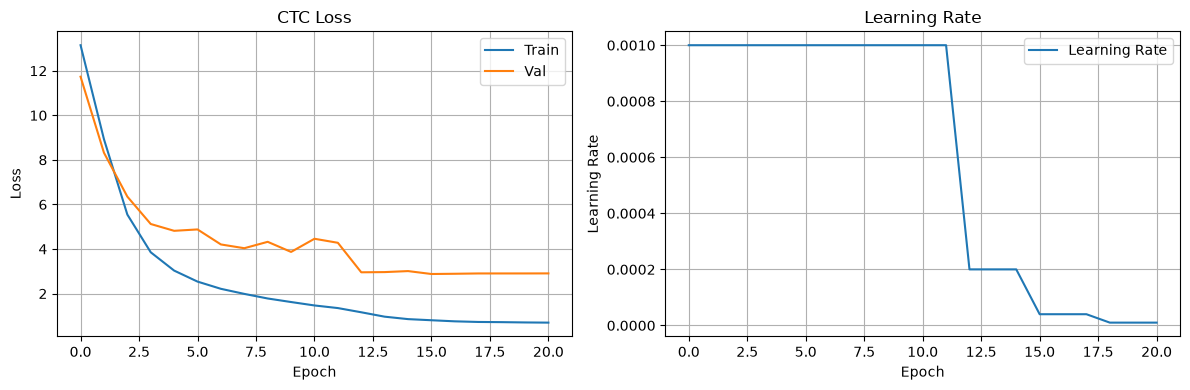

In [18]:
if 'history' in locals():

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # CTC Loss
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('CTC Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Learning Rate
    if 'learning_rate' in history.history:
        axes[1].plot(history.history['learning_rate'], label='Learning Rate')
        axes[1].set_title('Learning Rate')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Learning Rate')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## 13. Evaluation (CER / WER)

In [15]:
def evaluate_model(dataset, max_batches=None):
    total_cer, total_wer = 0, 0
    correctly_decoded_words = 0
    total_chars, total_words = 0, 0
    
    for i, (imgs, labels_ext) in enumerate(dataset):
        if max_batches and i >= max_batches: break
        
        preds = model.predict(imgs, verbose=0)
        pred_texts = decode_batch(preds)
        
        real_labels = labels_ext[:, :-1]
        label_lengths = labels_ext[:, -1]
        
        for idx in range(len(imgs)):
            length = label_lengths[idx].numpy()
            true_label = real_labels[idx][:length].numpy()
            true_text = "".join([num_to_char[c] for c in true_label])
            pred_text = pred_texts[idx]
            
            cer = editdistance.eval(true_text, pred_text)
            total_cer += cer
            total_chars += len(true_text)
            
            if true_text == pred_text:
                correctly_decoded_words += 1
            else:
                total_wer += 1
            total_words += 1
            
    word_accuracy = correctly_decoded_words / total_words if total_words > 0 else 0.0
    print(f"Word Accuracy: {word_accuracy:.4f}")
    print(f"CER: {total_cer / total_chars:.4f}")
    print(f"WER: {total_wer / total_words:.4f}")


In [16]:
print("Evaluating on Test Set:")
evaluate_model(test_ds)


Evaluating on Test Set:
Word Accuracy: 0.6351
CER: 0.1621
WER: 0.3649


## 14. Example Predictions & Error Analysis

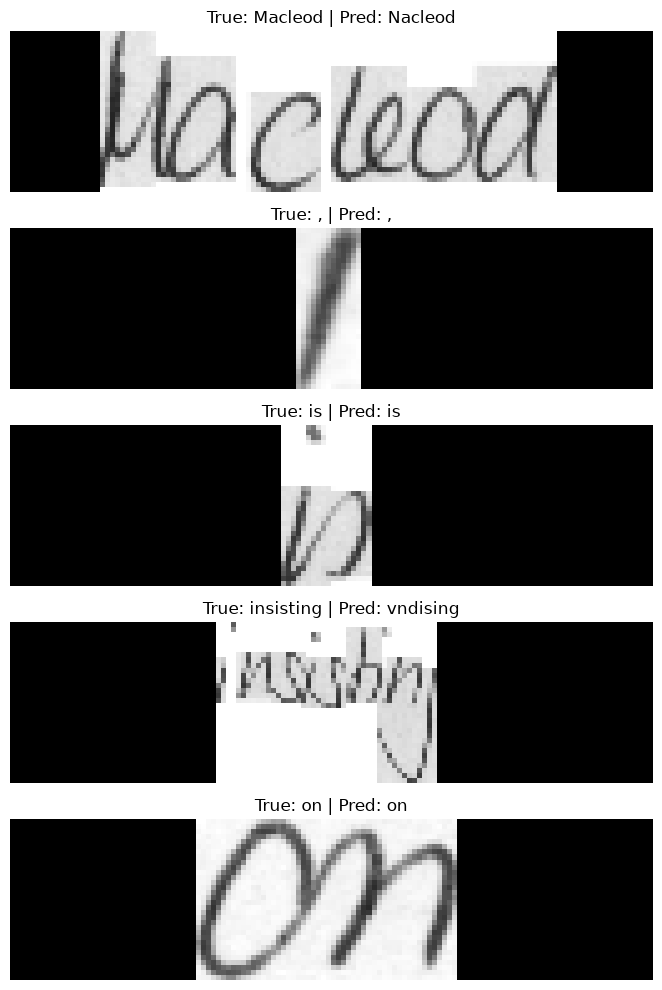

In [17]:
def plot_predictions(dataset, num_samples=5):
    for imgs, labels_ext in dataset.take(1):
        preds = model.predict(imgs, verbose=0)
        pred_texts = decode_batch(preds)
        
        real_labels = labels_ext[:, :-1]
        label_lengths = labels_ext[:, -1]
        
        fig, axes = plt.subplots(num_samples, 1, figsize=(10, 2*num_samples))
        if num_samples == 1: axes = [axes]
        for i in range(min(num_samples, len(imgs))):
            img = imgs[i].numpy()
            img = np.transpose(img, (1, 0, 2)) # back to height x width
            axes[i].imshow(img.squeeze(), cmap='gray')
            
            length = label_lengths[i].numpy()
            true_label = real_labels[i][:length].numpy()
            true_text = "".join([num_to_char[c] for c in true_label])
            
            axes[i].set_title(f"True: {true_text} | Pred: {pred_texts[i]}")
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()

plot_predictions(test_ds)


## 15. Conclusion

*(To be completed after review of CER/WER and visual inspections)*